In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import *
from random import seed
from scipy import stats
import seaborn as sns
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV
import statsmodels.api as sm
from statsmodels.stats.api import anova_lm
from statsmodels.formula.api import ols
from statsmodels.regression import linear_model
from sklearn.metrics import explained_variance_score
from statsmodels.stats.mediation import Mediation
from sklearn.linear_model import LassoCV, RidgeCV, Lasso
from pingouin import ancova
import matplotlib.cm as cm
from scipy.stats.stats import pearsonr


%matplotlib inline

seed(888)
pd.set_option('display.max_columns', None)

/tmp/ipykernel_1336473/3379509306.py:18: DeprecationWarning: Please use `pearsonr` from the `scipy.stats` namespace, the `scipy.stats.stats` namespace is deprecated.
  from scipy.stats.stats import pearsonr
/home/ubuntu/.local/lib/python3.8/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.2, the latest is 0.5.5.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


# 1 Load data from "2 BrainAge"

In [3]:
# load data from pickle and convert to dataframe
main_test = pd.read_pickle("2_main_test.pkl")
main_train = pd.read_pickle("2_main_train.pkl")
main_test = pd.DataFrame(main_test)
main_train = pd.DataFrame(main_train)

# 2 Preprocessing and descriptives

## 2.1 Data

In [4]:
main_test.head()

,ID,Age,Sex,IS,TPA,VPA,MPA,MVPA,LPA,SRLPA,SRMPA,SRVPA,HG,HR,BMI,DBP,SBP,EDUL,BADA2009,BADASEG,BADDesikan,BADCombined
10,1001365,71.0,Female,11025,3396.9600,20.1600,514.0800,554.4000,2862.7200,594.0,240.0,240.0,20.0,73.0,28.2030,70.0,106.0,O levels/GCSEs or equivalent,-3.486299,-5.838179,-0.570329,-4.474471
17,1001748,48.0,Female,11025,3126.8160,265.3056,596.9376,1127.5488,2264.5728,462.0,0.0,2400.0,34.0,52.0,25.7857,75.0,124.0,O levels/GCSEs or equivalent,4.423063,-2.317228,4.906249,-0.154642
20,1001984,69.0,Female,11026,2468.4192,9.9936,579.6288,599.6160,1878.7968,693.0,960.0,0.0,26.0,76.0,25.7422,79.0,120.0,O levels/GCSEs or equivalent,1.440781,-3.981057,-7.374432,-0.475284
21,1002138,56.0,Female,11025,2465.2224,29.1168,427.0464,485.2800,2009.0592,2970.0,720.0,240.0,18.0,56.0,33.5680,75.0,134.0,O levels/GCSEs or equivalent,-4.521025,-11.426624,1.934800,-4.658802
23,1002288,63.0,Female,11025,2559.7728,109.1376,704.4336,922.7088,1746.2016,264.0,960.0,0.0,30.0,85.0,27.4762,84.0,146.0,College or University degree,-4.928350,-4.316512,-4.312372,-3.613458


## 2.2 Remove outliers on SR PA

In [5]:
# remove outliers on self-reported physical activity data for each intensity seperately
before = main_test.shape[0]
outlier = np.mean(main_test["SRLPA"]) + np.std(main_test["SRLPA"])*3
main_test = main_test[main_test["SRLPA"]<outlier]
outlier = np.mean(main_test["SRMPA"]) + np.std(main_test["SRMPA"])*3
main_test = main_test[main_test["SRMPA"]<outlier]
outlier = np.mean(main_test["SRVPA"]) + np.std(main_test["SRVPA"])*3
main_test = main_test[main_test["SRVPA"]<outlier]
after = main_test.shape[0]
print("Outliers on self-reported PA:", before-after)
print(after)

Outliers on self-reported PA: 563
5422


## 2.3 Convert SRPA from MET min/week to min/week

In [6]:
main_test["SRLPA"] = main_test["SRLPA"]/3.3
main_test["SRMPA"] = main_test["SRMPA"]/4
main_test["SRVPA"] = main_test["SRVPA"]/8

main_train["SRLPA"] = main_train["SRLPA"]/3.3
main_train["SRMPA"] = main_train["SRMPA"]/4
main_train["SRVPA"] = main_train["SRVPA"]/8

## 2.4 Education preprocessing

In [7]:
edu = main_test[main_test["EDUL"]=="Prefer not to answer"].index
main_test = main_test.drop(edu)
print("People removed due to mising education", len(edu))

People removed due to mising education 12


## 2.5 Test set descriptives

In [8]:
# get mean and std for all variables for males and females seperately for the test set
female = main_test[main_test["Sex"] == "Female"]
male = main_test[main_test["Sex"]== "Male"]

print("Number of females:", female.shape[0])
print("NUmber of males:", male.shape[0])

print("Age")
mean = main_test["Age"].mean()
print("Mean", mean)
std = main_test["Age"].std()
print("Std",std)

print("LPA")
mean = main_test["LPA"].mean()
print("Mean", mean)
std = main_test["LPA"].std()
print("Std",std)

print("MPA")
mean = main_test["MPA"].mean()
print("Mean", mean)
std = main_test["MPA"].std()
print("Std",std)

print("VPA")
mean = main_test["VPA"].mean()
print("Mean", mean)
std = main_test["VPA"].std()
print("Std",std)

print("SRLPA")
mean = main_test["SRLPA"].mean()
print("Mean", mean)
std = main_test["SRLPA"].std()
print("Std",std)

print("SRMPA")
mean = main_test["SRMPA"].mean()
print("Mean", mean)
std = main_test["SRMPA"].std()
print("Std",std)

print("SRVPA")
mean = main_test["SRVPA"].mean()
print("Mean", mean)
std = main_test["SRVPA"].std()
print("Std",std)

print("DBP")
mean = main_test["DBP"].mean()
print("Mean", mean)
std = main_test["DBP"].std()
print("Std",std)

print("SBP")
mean = main_test["SBP"].mean()
print("Mean", mean)
std = main_test["SBP"].std()
print("Std",std)

print("BMI")
mean = main_test["BMI"].mean()
print("Mean", mean)
std = main_test["BMI"].std()
print("Std",std)

print("HG")
mean = main_test["HG"].mean()
print("Mean", mean)
std = main_test["HG"].std()
print("Std",std)

print("HR")
mean = main_test["HR"].mean()
print("Mean", mean)
std = main_test["HR"].std()
print("Std",std)

print("IS")
print(main_test["IS"].value_counts())

print("EDUL")
print(main_test["EDUL"].value_counts())

Number of females: 2893
NUmber of males: 2517
Age
Mean 64.4166358595194
Std 7.743423223084423
LPA
Mean 1976.9216845841036
Std 414.8292137777303
MPA
Mean 484.4173548243994
Std 223.4087277242472
VPA
Mean 33.87367896487988
Std 44.57648961925181
SRLPA
Mean 233.96783733826248
Std 216.21816560690934
SRMPA
Mean 158.59907578558224
Std 191.4536434159878
SRVPA
Mean 64.17744916820702
Std 82.65668678330978
DBP
Mean 81.12421441774492
Std 10.413972722407959
SBP
Mean 136.5894639556377
Std 18.799893004289288
BMI
Mean 26.334092033271716
Std 4.2281519593890495
HG
Mean 33.6090573012939
Std 10.95014801623315
HR
Mean 67.98040665434381
Std 10.696072914887235
IS
11025    3322
11027    1150
11026     933
11028       5
Name: IS, dtype: int64
EDUL
College or University degree                               2833
O levels/GCSEs or equivalent                                975
A levels/AS levels or equivalent                            713
NVQ or HND or HNC or equivalent                             248
None of the 

## 2.6 Train set descriptives

In [9]:
# # get mean and std for all variables for males and females seperately for the test set
# female = main_train[main_train["Sex"] == "Female"]
# male = main_train[main_train["Sex"]== "Male"]

# print("Number of females:", female.shape[0])
# print("NUmber of males:", male.shape[0])

# print("Age")
# mean = main_train["Age"].mean()
# print("Mean", mean)
# std = main_train["Age"].std()
# print("Std",std)

# print("SRLPA")
# mean = main_train["SRLPA"].mean()
# print("Mean", mean)
# std = main_train["SRLPA"].std()
# print("Std",std)

# print("SRMPA")
# mean = main_train["SRMPA"].mean()
# print("Mean", mean)
# std = main_train["SRMPA"].std()
# print("Std",std)

# print("SRVPA")
# mean = main_train["SRVPA"].mean()
# print("Mean", mean)
# std = main_train["SRVPA"].std()
# print("Std",std)

# print("DBP")
# mean = main_train["DBP"].mean()
# print("Mean", mean)
# std = main_train["DBP"].std()
# print("Std",std)

# print("SBP")
# mean = main_train["SBP"].mean()
# print("Mean", mean)
# std = main_train["SBP"].std()
# print("Std",std)

# print("BMI")
# mean = main_train["BMI"].mean()
# print("Mean", mean)
# std = main_train["BMI"].std()
# print("Std",std)

# print("HG")
# mean = main_train["HG"].mean()
# print("Mean", mean)
# std = main_train["HG"].std()
# print("Std",std)

# print("HR")
# mean = main_train["HR"].mean()
# print("Mean", mean)
# std = main_train["HR"].std()
# print("Std",std)

# print("IS")
# print(main_train["IS"].value_counts())

# print("EDUL")
# print(main_train["EDUL"].value_counts())

## 2.7 Physical activity

In [10]:
# plot physical activity intensity categories for self-report and accelerometer together and seperately

# plt.figure()
# sns.kdeplot(data = main_test, x= 'LPA', fill=True, label = "Light PA")
# sns.kdeplot(data = main_test, x= 'MPA', fill=True, label = "Moderate PA")
# sns.kdeplot(data = main_test, x= 'VPA', fill=True, label = "Vigorous PA")
# plt.xlabel("Min/week of physical activity", fontsize = 16)
# plt.xticks(range(0,5000,1000),fontsize = 14)
# plt.ylabel("Density",fontsize = 16)
# plt.yticks(fontsize = 14)
# plt.legend()
# plt.show()

# plt.figure()
# sns.kdeplot(data = main_test, x= 'SRLPA', fill=True, label = "SR Light PA")
# sns.kdeplot(data = main_test, x= 'SRMPA', fill=True, label = "SR Moderate PA")
# sns.kdeplot(data = main_test, x= 'SRVPA', fill=True, label = "SR Vigorous PA")
# plt.xlabel("Min/week of physical activity", fontsize = 16)
# plt.xticks(range(0,2000,500),fontsize = 14)
# plt.yticks(fontsize = 14)
# plt.ylabel("Density",fontsize = 16)
# plt.legend()
# plt.show()

# plt.figure()
# sns.kdeplot(data = main_test, x= 'SRLPA', fill=True, label = "SR Light PA", color="#6baed6")
# sns.kdeplot(data = main_test, x= 'LPA', fill=True, label = "Light PA", color="#08519c")
# plt.xlabel("Min/week of physical activity", fontsize = 16)
# plt.xticks(range(0,4500,1000),fontsize = 14)
# plt.yticks(fontsize = 14)
# plt.ylabel("Density",fontsize = 16)
# plt.legend()
# plt.show()

# plt.figure()
# sns.kdeplot(data = main_test, x= 'SRMPA', fill=True, label = "SR Moderate PA", color="#fd8d3c")
# sns.kdeplot(data = main_test, x= 'MPA', fill=True, label = "Moderate PA", color="#a63603")
# plt.xlabel("Min/week of physical activity", fontsize = 16)
# plt.xticks(range(0,2500,500),fontsize = 14)
# plt.yticks(fontsize = 14)
# plt.ylabel("Density",fontsize = 16)
# plt.legend()
# plt.show()

# plt.figure()
# sns.kdeplot(data = main_test, x= 'SRVPA', fill=True, label = "SR Vigorous PA", color="#74c476")
# sns.kdeplot(data = main_test, x= 'VPA', fill=True, label = "Vigorous PA", color="#006d2c")
# plt.ylim(0,0.01)
# plt.xticks(range(0,1500,500),fontsize = 14)
# plt.yticks(fontsize = 14)
# plt.ylabel("Density",fontsize = 16)
# plt.xlabel("Min/week of physical activity", fontsize = 16)
# plt.legend()
# plt.show()

# plt.figure()
# plt.scatter("MPA", "SRMPA", data = main_test, label = "Moderate PA", alpha=0.3, s=10, color = "darkcyan")
# plt.scatter("VPA", "SRVPA", data = main_test, label = "Vigorous PA", alpha=0.3, s=10, color = "mediumvioletred")
# plt.ylabel("Self-reported (min/week)", fontsize = 16)
# plt.xlabel("Accelerometer (min/week)", fontsize = 16)
# plt.xticks(fontsize = 14)
# plt.yticks(fontsize = 14)
# plt.legend(loc="best")
# plt.show()

# 3 Recode variables

In [11]:
# recode Imaging site and Gender
# 1 = Cheadle;  2 = Reading;  3 = Newcastle;  4 = Bristol
main_test['IS'] = main_test['IS'].map({'11025': 0, '11026': 1,'11027': 2, '11028': 3})
main_test['EDUL'] = main_test['EDUL'].map({'None of the above': 0, 'Other professional qualifications eg: nursing, teaching': 5,'NVQ or HND or HNC or equivalent': 4, 'CSEs or equivalent': 1, 'O levels/GCSEs or equivalent':2, 'A levels/AS levels or equivalent':3,'College or University degree':6})
main_test["Sex"] = main_test["Sex"].map({"Female":0, "Male":1})
main_test["Sex"] = main_test["Sex"].astype("int")
main_test = main_test.rename(columns={"BADCombined": "BA"})

main_test = pd.get_dummies(main_test, columns=["IS"], prefix="IS", drop_first=True)

print("EDU")
print(main_test["EDUL"].value_counts())

EDU
6.0    2833
2.0     975
3.0     713
4.0     248
0.0     244
5.0     228
1.0     169
Name: EDUL, dtype: int64


# 4 Reorder dataframe and delete unused variables

In [12]:
main_test = main_test[['Age', 'Sex', 'IS_1', "IS_2", "IS_3" , "EDUL", 'LPA', 'MPA', 'VPA', 'SRLPA', 'SRMPA', 'SRVPA', 'HG', 'HR', 'BMI', 'DBP', 'SBP', 'BA']]

# 5 Standardization of all variables

In [13]:
main_test = pd.DataFrame(main_test)
main_test[["LPA", "MPA","VPA","SRLPA","SRMPA","SRVPA","HR", "DBP", "SBP", "HG","BMI","Age","Sex", 'IS_1', "IS_2", "IS_3", "EDUL"]] = stats.zscore(main_test[["LPA", "MPA","VPA","SRLPA","SRMPA","SRVPA","HR", "DBP", "SBP", "HG","BMI","Age","Sex", 'IS_1', "IS_2", "IS_3", "EDUL"]], nan_policy='omit')

# 6 Correlation heatmap

In [14]:
def calculate_pvalues(df):
    dfcols = pd.DataFrame(columns=df.columns)
    pvalues = dfcols.transpose().join(dfcols, how='outer')
    for r in df.columns:
        for c in df.columns:
            tmp = df[df[r].notnull() & df[c].notnull()]
            pvalues[r][c] = round(pearsonr(tmp[r], tmp[c])[1], 4)
    return pvalues

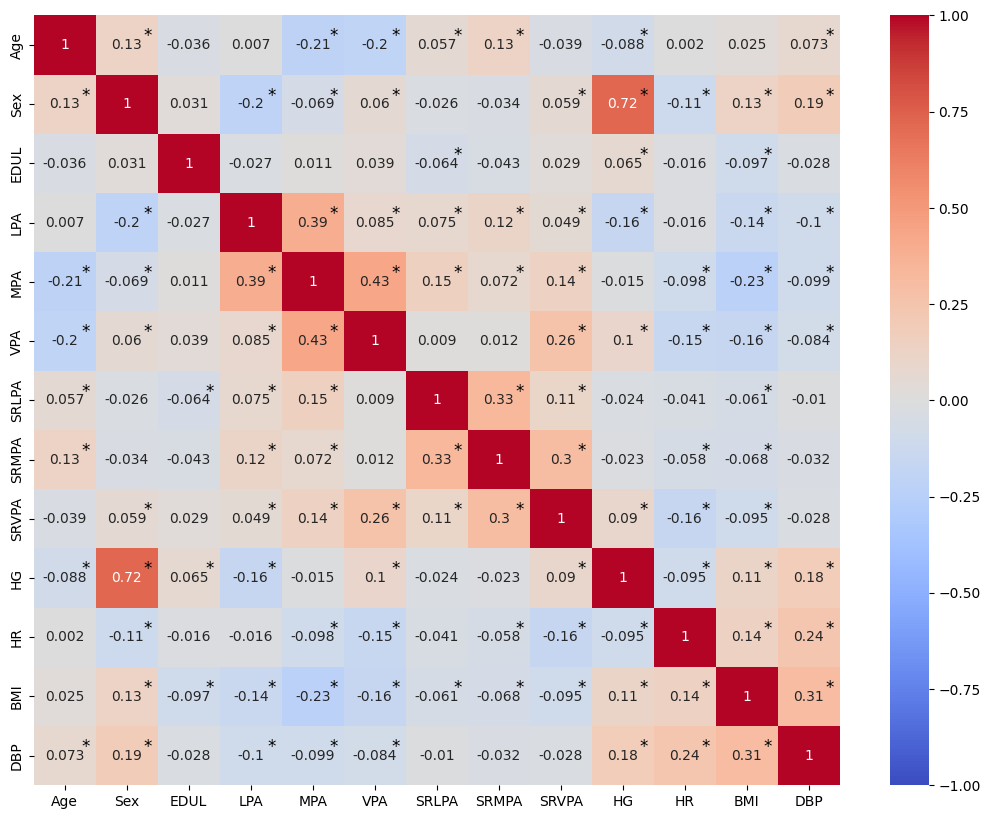

In [15]:
corr_test = main_test
corr_test = corr_test[:]
del corr_test["BA"]
del corr_test["SBP"]
del corr_test["IS_1"]
del corr_test["IS_2"]
del corr_test["IS_3"]
corr = corr_test.corr()
corr = round(corr,3)

fig, ax = plt.subplots(figsize=(13,10)) 
sns.heatmap(corr, annot=True, cmap = "coolwarm", vmin=-1, vmax=1)
plt.xticks(size=10)
plt.yticks(size=10)


p_values = np.asarray(calculate_pvalues(corr_test))

threshold = 0.0007575  # Define your significance threshold

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        if i != j:
            correlation = corr.iloc[i, j]
            p_value = p_values[i,j]  # Calculate or provide the p-value for the correlation

            if p_value < threshold:
                ax.text(j + 0.9, i + 0.2, "*", ha='right', va='top', color='black', fontsize=12)

plt.savefig('eduheatmap.png', format='png', dpi=800)               
plt.show()

# 7 Models OLS

## 7.1 Baseline Covariates

In [16]:
cov_model = ols('BA ~ Sex + Age + IS_1 + IS_2 + IS_3 + EDUL', missing='drop', data = main_test).fit()
print(cov_model.summary())

#calculate effect size
results = cov_model
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     7.164
Date:                Sat, 22 Feb 2025   Prob (F-statistic):           1.26e-07
Time:                        15:01:28   Log-Likelihood:                -17125.
No. Observations:                5410   AIC:                         3.426e+04
Df Residuals:                    5403   BIC:                         3.431e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1692      0.078     -2.168      0.0

## 7.2 Accelerometer PA

In [17]:
lpa = ols('BA ~ LPA + Age + Sex + IS_1 + IS_2 + IS_3 + EDUL + Sex:LPA + EDUL:LPA', missing='drop', data = main_test).fit()
print(lpa.summary())

#calculate effect size
results = lpa
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     5.023
Date:                Sat, 22 Feb 2025   Prob (F-statistic):           9.04e-07
Time:                        15:01:28   Log-Likelihood:                -17124.
No. Observations:                5410   AIC:                         3.427e+04
Df Residuals:                    5400   BIC:                         3.433e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1692      0.080     -2.122      0.0

In [18]:
mpa = ols('BA ~ MPA + Age + Sex + IS_1 + IS_2 + IS_3 + EDUL + Sex:MPA + EDUL:MPA', missing='drop', data = main_test).fit()
print(mpa.summary())

#calculate effect size
results = mpa
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     6.665
Date:                Sat, 22 Feb 2025   Prob (F-statistic):           1.53e-09
Time:                        15:01:28   Log-Likelihood:                -17117.
No. Observations:                5410   AIC:                         3.425e+04
Df Residuals:                    5400   BIC:                         3.432e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1856      0.078     -2.376      0.0

In [19]:
vpa = ols('BA ~ VPA + Age + Sex + IS_1 + IS_2 + IS_3 + EDUL + Sex:VPA + EDUL:VPA', missing='drop', data = main_test).fit()
print(vpa.summary())

#calculate effect size
results = vpa
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     5.538
Date:                Sat, 22 Feb 2025   Prob (F-statistic):           1.26e-07
Time:                        15:01:28   Log-Likelihood:                -17122.
No. Observations:                5410   AIC:                         3.426e+04
Df Residuals:                    5400   BIC:                         3.433e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1614      0.078     -2.064      0.0

## 7.3 Self-report PA

In [20]:
srlpa = ols('BA ~ SRLPA + Age + Sex + IS_1 + IS_2 + IS_3 + EDUL + Sex:SRLPA + EDUL:SRLPA', missing='drop', data = main_test).fit()
print(srlpa.summary())

#calculate effect size
results = srlpa
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     5.093
Date:                Sat, 22 Feb 2025   Prob (F-statistic):           6.93e-07
Time:                        15:01:28   Log-Likelihood:                -17124.
No. Observations:                5410   AIC:                         3.427e+04
Df Residuals:                    5400   BIC:                         3.433e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1717      0.078     -2.196      0.0

In [21]:
srmpa = ols('BA ~ SRMPA + Age + Sex + IS_1 + IS_2 + IS_3 + EDUL + Sex:SRMPA + EDUL:SRMPA', missing='drop', data = main_test).fit()
print(srmpa.summary())

#calculate effect size
results = srmpa
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     5.777
Date:                Sat, 22 Feb 2025   Prob (F-statistic):           4.98e-08
Time:                        15:01:28   Log-Likelihood:                -17121.
No. Observations:                5410   AIC:                         3.426e+04
Df Residuals:                    5400   BIC:                         3.433e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1674      0.078     -2.143      0.0

In [22]:
srvpa = ols('BA ~ SRVPA + Age + Sex + IS_1 + IS_2 + IS_3 + EDUL + Sex:SRVPA + EDUL:SRVPA', missing='drop', data = main_test).fit()
print(srvpa.summary())

#calculate effect size
results = srvpa
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     5.683
Date:                Sat, 22 Feb 2025   Prob (F-statistic):           7.17e-08
Time:                        15:01:29   Log-Likelihood:                -17121.
No. Observations:                5410   AIC:                         3.426e+04
Df Residuals:                    5400   BIC:                         3.433e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1641      0.078     -2.100      0.0

# 8 Model comparisons

## 8.1 Cov vs. PA

In [23]:
model_comparison = anova_lm(cov_model, lpa)
print(model_comparison)

   df_resid            ssr  df_diff    ss_diff         F    Pr(>F)
0    5403.0  177926.078665      0.0        NaN       NaN       NaN
1    5400.0  177852.710103      3.0  73.368562  0.742544  0.526576


In [24]:
model_comparison = anova_lm(cov_model, mpa)
print(model_comparison)

   df_resid            ssr  df_diff     ss_diff         F    Pr(>F)
0    5403.0  177926.078665      0.0         NaN       NaN       NaN
1    5400.0  177371.222774      3.0  554.855891  5.630793  0.000752


In [25]:
model_comparison = anova_lm(cov_model, vpa)
print(model_comparison)

   df_resid            ssr  df_diff     ss_diff         F    Pr(>F)
0    5403.0  177926.078665      0.0         NaN       NaN       NaN
1    5400.0  177701.508051      3.0  224.570614  2.274753  0.077842


## 8.2 Cov vs. SRPA

In [26]:
model_comparison = anova_lm(cov_model, srlpa)
print(model_comparison)

   df_resid            ssr  df_diff    ss_diff         F    Pr(>F)
0    5403.0  177926.078665      0.0        NaN       NaN       NaN
1    5400.0  177832.117393      3.0  93.961272  0.951067  0.414896


In [27]:
model_comparison = anova_lm(cov_model, srmpa)
print(model_comparison)

   df_resid            ssr  df_diff     ss_diff         F    Pr(>F)
0    5403.0  177926.078665      0.0         NaN       NaN       NaN
1    5400.0  177631.339220      3.0  294.739445  2.986697  0.029916


In [28]:
model_comparison = anova_lm(cov_model, srvpa)
print(model_comparison)

   df_resid            ssr  df_diff    ss_diff         F    Pr(>F)
0    5403.0  177926.078665      0.0        NaN       NaN       NaN
1    5400.0  177658.908515      3.0  267.17015  2.706908  0.043686


# 9 Mediation analysis

## 9.1 BMI

In [29]:
# outcome_model = sm.OLS.from_formula("BA ~ BMI + LPA + Gender + Age", main_test)
# mediator_model = sm.OLS.from_formula("BMI ~ LPA + Gender + Age", main_test)
# res = Mediation(outcome_model, mediator_model, mediator = "BMI", exposure = "LPA").fit()
# print(res.summary())

In [30]:
outcome_model = sm.OLS.from_formula("BA ~ BMI + MPA + Age + Sex + IS_1 + IS_2 + IS_3 + EDUL", main_test)
mediator_model = sm.OLS.from_formula("BMI ~ MPA + Age + Sex + IS_1 + IS_2 + IS_3 + EDUL", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "BMI", exposure = "MPA").fit()
print(res.summary())

modelm = ols("BMI ~ MPA + Age + Sex + IS_1 + IS_2 + IS_3 + EDUL", missing='drop', data = main_test).fit()
print(modelm.summary())
modely = ols("BA ~ BMI + Age + Sex + IS_1 + IS_2 + IS_3 + EDUL", missing='drop', data = main_test).fit()
print(modely.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)           -0.034644       -0.072132        0.003900    0.082
ACME (treated)           -0.034644       -0.072132        0.003900    0.082
ADE (control)            -0.124199       -0.290213        0.037252    0.144
ADE (treated)            -0.124199       -0.290213        0.037252    0.144
Total effect             -0.158842       -0.310179        0.005832    0.058
Prop. mediated (control)  0.205509       -0.417878        1.443233    0.140
Prop. mediated (treated)  0.205509       -0.417878        1.443233    0.140
ACME (average)           -0.034644       -0.072132        0.003900    0.082
ADE (average)            -0.124199       -0.290213        0.037252    0.144
Prop. mediated (average)  0.205509       -0.417878        1.443233    0.140
                            OLS Regression Results                            
Dep. Variable:                    BMI   R-squared:                       0.083
Model:

In [31]:
# outcome_model = sm.OLS.from_formula("BA ~ BMI + VPA + Age + Gender", main_test)
# mediator_model = sm.OLS.from_formula("BMI ~ VPA + Age + Gender", main_test)
# res = Mediation(outcome_model, mediator_model, mediator = "BMI", exposure = "VPA").fit()
# print(res.summary())

## 9.2 DBP

In [32]:
# outcome_model = sm.OLS.from_formula("BA ~ DBP + LPA + Age + Gender", main_test)
# mediator_model = sm.OLS.from_formula("DBP ~ LPA + Age + Gender", main_test)
# res = Mediation(outcome_model, mediator_model, mediator = "DBP", exposure = "LPA").fit()
# print(res.summary())

In [33]:
outcome_model = sm.OLS.from_formula("BA ~ DBP + MPA + Age + Sex + IS_1 + IS_2 + IS_3 + EDUL", main_test)
mediator_model = sm.OLS.from_formula("DBP ~ MPA + Age + Sex + IS_1 + IS_2 + IS_3 + EDUL", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "DBP", exposure = "MPA").fit()
print(res.summary())

modelm = ols("DBP ~ MPA + Age + Sex + IS_1 + IS_2 + IS_3 + EDUL", missing='drop', data = main_test).fit()
print(modelm.summary())
modely = ols("BA ~ DBP + Age + Sex + IS_1 + IS_2 + IS_3 + EDUL", missing='drop', data = main_test).fit()
print(modely.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)           -0.032763       -0.058060       -0.012974    0.000
ACME (treated)           -0.032763       -0.058060       -0.012974    0.000
ADE (control)            -0.120094       -0.268683        0.042300    0.140
ADE (treated)            -0.120094       -0.268683        0.042300    0.140
Total effect             -0.152857       -0.304854        0.012730    0.072
Prop. mediated (control)  0.198547       -0.735456        1.154333    0.072
Prop. mediated (treated)  0.198547       -0.735456        1.154333    0.072
ACME (average)           -0.032763       -0.058060       -0.012974    0.000
ADE (average)            -0.120094       -0.268683        0.042300    0.140
Prop. mediated (average)  0.198547       -0.735456        1.154333    0.072
                            OLS Regression Results                            
Dep. Variable:                    DBP   R-squared:                       0.047
Model:

In [34]:
# outcome_model = sm.OLS.from_formula("BA ~ DBP + VPA + Age + Gender", main_test)
# mediator_model = sm.OLS.from_formula("DBP ~ VPA + Age + Gender", main_test)
# res = Mediation(outcome_model, mediator_model, mediator = "DBP", exposure = "VPA").fit()
# print(res.summary())

## 9.3 Heart rate

In [35]:
# outcome_model = sm.OLS.from_formula("BA ~ HR + LPA + Age + Gender", main_test)
# mediator_model = sm.OLS.from_formula("HR ~ LPA + Age + Gender", main_test)
# res = Mediation(outcome_model, mediator_model, mediator = "HR", exposure = "LPA").fit()
# print(res.summary())

In [36]:
outcome_model = sm.OLS.from_formula("BA ~ HR + MPA + Age + Sex + IS_1 + IS_2 + IS_3 + EDUL", main_test)
mediator_model = sm.OLS.from_formula("HR ~ MPA + Age + Sex + IS_1 + IS_2 + IS_3 + EDUL", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "HR", exposure = "MPA").fit()
print(res.summary())

modelm = ols("HR ~ MPA + Age + Sex + IS_1 + IS_2 + IS_3 + EDUL", missing='drop', data = main_test).fit()
print(modelm.summary())
modely = ols("BA ~ HR + Age + Sex + IS_1 + IS_2 + IS_3 + EDUL", missing='drop', data = main_test).fit()
print(modely.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)           -0.040287       -0.069040       -0.019155    0.000
ACME (treated)           -0.040287       -0.069040       -0.019155    0.000
ADE (control)            -0.113579       -0.273212        0.044993    0.158
ADE (treated)            -0.113579       -0.273212        0.044993    0.158
Total effect             -0.153866       -0.314469        0.001739    0.056
Prop. mediated (control)  0.247879       -0.387950        1.854762    0.056
Prop. mediated (treated)  0.247879       -0.387950        1.854762    0.056
ACME (average)           -0.040287       -0.069040       -0.019155    0.000
ADE (average)            -0.113579       -0.273212        0.044993    0.158
Prop. mediated (average)  0.247879       -0.387950        1.854762    0.056
                            OLS Regression Results                            
Dep. Variable:                     HR   R-squared:                       0.026
Model:

In [37]:
# outcome_model = sm.OLS.from_formula("BA ~ HR + VPA + Age + Gender", main_test)
# mediator_model = sm.OLS.from_formula("HR ~ VPA + Age + Gender", main_test)
# res = Mediation(outcome_model, mediator_model, mediator = "HR", exposure = "VPA").fit()
# print(res.summary())

## 9.4 Hand grip

In [38]:
# outcome_model = sm.OLS.from_formula("BA ~ HG + LPA + Gender + Age", main_test)
# mediator_model = sm.OLS.from_formula("HG ~ LPA + Gender + Age", main_test)
# res = Mediation(outcome_model, mediator_model, mediator = "HG", exposure = "LPA").fit()
# print(res.summary())

In [39]:
outcome_model = sm.OLS.from_formula("BA ~ HG + MPA + Sex + Age + IS_1 + IS_2 + IS_3 + EDUL", main_test)
mediator_model = sm.OLS.from_formula("HG ~ MPA + Sex + Age + IS_1 + IS_2 + IS_3 + EDUL", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "HG", exposure = "MPA").fit()
print(res.summary())

modelm = ols("HG ~ MPA + Age + Sex + IS_1 + IS_2 + IS_3 + EDUL", missing='drop', data = main_test).fit()
print(modelm.summary())
modely = ols("BA ~ HG + Age + Sex + IS_1 + IS_2 + IS_3 + EDUL", missing='drop', data = main_test).fit()
print(modely.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)            0.001349       -0.011732        0.014164    0.818
ACME (treated)            0.001349       -0.011732        0.014164    0.818
ADE (control)            -0.159540       -0.315285       -0.008409    0.034
ADE (treated)            -0.159540       -0.315285       -0.008409    0.034
Total effect             -0.158191       -0.318044       -0.008488    0.038
Prop. mediated (control) -0.007896       -0.194327        0.163910    0.832
Prop. mediated (treated) -0.007896       -0.194327        0.163910    0.832
ACME (average)            0.001349       -0.011732        0.014164    0.818
ADE (average)            -0.159540       -0.315285       -0.008409    0.034
Prop. mediated (average) -0.007896       -0.194327        0.163910    0.832
                            OLS Regression Results                            
Dep. Variable:                     HG   R-squared:                       0.556
Model:

In [40]:
# outcome_model = sm.OLS.from_formula("BA ~ HG + VPA + Gender + Age", main_test)
# mediator_model = sm.OLS.from_formula("HG ~ VPA + Gender + Age", main_test)
# res = Mediation(outcome_model, mediator_model, mediator = "HG", exposure = "VPA").fit()
# print(res.summary())

# 10 LASSO Regression

## 10.1 Accelerometer PA

Optimal alpha: 0.023101297000831605


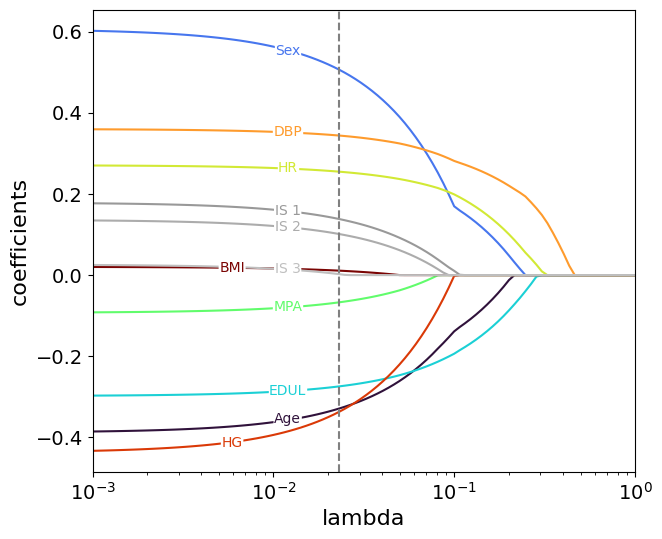

[-0.32884225  0.50631744 -0.27426225 -0.06707837  0.2549334   0.34395236
 -0.33695959  0.01098483  0.13825979  0.10127898  0.00239153]
0.017894693177765375


In [41]:
df = main_test[["Age","Sex","EDUL", "MPA", "SRMPA", "HR", "DBP", "HG", "BMI", "BA", "IS_1", "IS_2", "IS_3"]]
df = df.dropna()
df = pd.DataFrame(df)
X = df[["Age","Sex","EDUL", "MPA", "HR", "DBP", "HG", "BMI", "IS_1", "IS_2", "IS_3"]]
Y = df["BA"]
columns = ["Age","Sex","EDUL", "MPA", "HR", "DBP", "HG", "BMI", "IS 1", "IS 2", "IS 3"]

coefs = []
alphas = np.power(10,np.linspace(start=-3, stop=0, num=100))

for a in alphas:
    lasso = Lasso(alpha=a)
    lasso.fit(X,Y)
    coefs.append(lasso.coef_)

coefs = pd.DataFrame(coefs)
coefs.columns = columns
coefs = pd.DataFrame(coefs)


# lasso with cross validated alpha
lassocv = LassoCV(alphas = alphas, random_state=888).fit(X,Y)
best_alpha = lassocv.alpha_
print("Optimal alpha:", best_alpha)

# Get the coefficients of the Lasso model at the best lambda value
lasso = Lasso(alpha=best_alpha)
lasso.fit(X, Y)
coefficients = lasso.coef_
r_squared = lasso.score(X,Y)



cmap = cm.get_cmap('turbo')
plt.figure(figsize=(7,6))
grey_shades = np.linspace(0.6, 0.75, 3)  # Three shades of mid-grey

num_colorful = 8  # First 7 columns use the colormap
num_grey = 3  # Last 3 columns use shades of grey

for i, column in enumerate(columns):
    if i < num_colorful:
        color = cmap(i / (num_colorful - 1))  # Normalize within the first 7 columns
    else:
        color = (grey_shades[i - num_colorful],) * 3  # Different grey shades for last 3
    
    plt.plot(alphas, coefs[column], label=column, color=color)

for i, column in enumerate(columns):
    y_pos = coefficients[i]
    if i < num_colorful:
        color = cmap(i / (num_colorful - 1))  # Normalize within the first 7 columns
    else:
        color = (grey_shades[i - num_colorful],) * 3

    if i == 0:
        plt.annotate(column, (0.012, y_pos), textcoords="offset points", xytext=(0, -10),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    elif i == 1:
        plt.annotate(column, (0.012, y_pos), textcoords="offset points", xytext=(0, 11),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='square', facecolor='white', edgecolor="white", pad=0))
    elif i == 2:
        plt.annotate(column, (0.012, y_pos), textcoords="offset points", xytext=(0, -6),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='square', facecolor='white', edgecolor="white", pad=0))
    elif i == 3:
        plt.annotate(column, (0.012, y_pos), textcoords="offset points", xytext=(0, -6),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='square', facecolor='white', edgecolor="white", pad=0))
    elif i == 4:
        plt.annotate(column, (0.012, y_pos), textcoords="offset points", xytext=(0, 0),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='square', facecolor='white', edgecolor="white", pad=0))
    elif i == 5:
        plt.annotate(column, (0.012, y_pos), textcoords="offset points", xytext=(0, 0),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='square', facecolor='white', edgecolor="white", pad=0))
    elif i == 6:
        plt.annotate(column, (0.012, y_pos), textcoords="offset points", xytext=(-40, -25),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    elif i == 7:
        plt.annotate(column, (0.012, y_pos), textcoords="offset points", xytext=(-40, -1),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    elif i == 8:
        plt.annotate(column, (0.012, y_pos), textcoords="offset points", xytext=(0, 3),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    elif i == 9:
        plt.annotate(column, (0.012, y_pos), textcoords="offset points", xytext=(0, 2),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    elif i == 10:
        plt.annotate(column, (0.012, y_pos), textcoords="offset points", xytext=(0, 1),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
        
        
plt.xticks(alphas, fontsize = 14)
plt.yticks(fontsize = 14)
plt.xscale("log")
plt.axvline(x = best_alpha, color = 'gray', linestyle='dashed')
plt.axis('tight')
plt.xlabel('lambda', fontsize = 16)
plt.xlim(0.001, 1)
plt.ylabel('coefficients', fontsize = 16)
plt.legend().set_visible(False)
plt.savefig('edulasso.png', format='png', dpi=800)
plt.show()

# Print the coefficients
print(coefficients)
print(r_squared)

## 10.2 Self-report PA

Optimal alpha: 0.021544346900318846


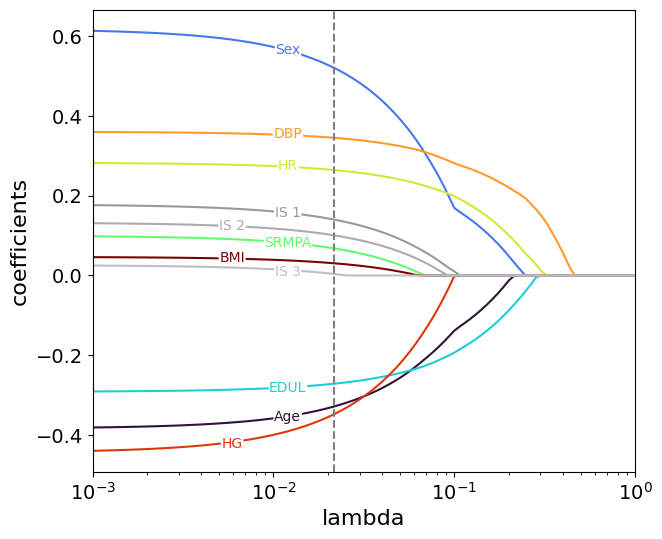

[-0.32872219  0.52106946 -0.27143064  0.06812627  0.26451561  0.34532395
 -0.34827082  0.03073297  0.14040496  0.100891    0.00388862]
0.017979276875054073


In [42]:
df = main_test[["Age", "Sex", "EDUL", "LPA", "MPA", "VPA",  "SRLPA", "SRMPA", "SRVPA", "HR", "DBP", "HG", "BMI", "BA", "IS_1", "IS_2", "IS_3"]]
df = df.dropna()
df = pd.DataFrame(df)
X = df[["Age", "Sex", "EDUL", "SRMPA", "HR", "DBP", "HG", "BMI", "IS_1", "IS_2", "IS_3"]]
Y = df["BA"]
columns = ["Age", "Sex", "EDUL", "SRMPA", "HR", "DBP", "HG", "BMI", "IS 1", "IS 2", "IS 3"]

coefs = []
alphas = np.power(10,np.linspace(start=-3, stop=0, num=100))

for a in alphas:
    lasso = Lasso(alpha=a)
    lasso.fit(X,Y)
    coefs.append(lasso.coef_)

coefs = pd.DataFrame(coefs)
coefs.columns = columns
coefs = pd.DataFrame(coefs)

# lasso with cross validated alpha
lassocv = LassoCV(alphas = alphas, random_state=888).fit(X,Y)
best_alpha = lassocv.alpha_
print("Optimal alpha:", best_alpha)


# Get the coefficients of the Lasso model at the best lambda value
lasso = Lasso(alpha=best_alpha)
lasso.fit(X, Y)
coefficients = lasso.coef_
r_squared = lasso.score(X,Y)


cmap = cm.get_cmap('turbo')
plt.figure(figsize=(7,6))
grey_shades = np.linspace(0.6, 0.75, 3)  # Three shades of mid-grey

num_colorful = 8  # First 7 columns use the colormap
num_grey = 3  # Last 3 columns use shades of grey

for i, column in enumerate(columns):
    if i < num_colorful:
        color = cmap(i / (num_colorful - 1))  # Normalize within the first 7 columns
    else:
        color = (grey_shades[i - num_colorful],) * 3  # Different grey shades for last 3
    
    plt.plot(alphas, coefs[column], label=column, color=color)



for i, column in enumerate(columns):
    y_pos = coefficients[i]
    if i < num_colorful:
        color = cmap(i / (num_colorful - 1))  # Normalize within the first 7 columns
    else:
        color = (grey_shades[i - num_colorful],) * 3
    
    if i == 0:
        plt.annotate(column, (0.012, y_pos), textcoords="offset points", xytext=(0, -10),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    elif i == 1:
        plt.annotate(column, (0.012, y_pos), textcoords="offset points", xytext=(0, 10),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='square', facecolor='white', edgecolor="white", pad=0))
    elif i == 2:
        plt.annotate(column, (0.012, y_pos), textcoords="offset points", xytext=(0, -6),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='square', facecolor='white', edgecolor="white", pad=0))
    elif i == 3:
        plt.annotate(column, (0.012, y_pos), textcoords="offset points", xytext=(0, 1),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='square', facecolor='white', edgecolor="white", pad=0))
    elif i == 4:
        plt.annotate(column, (0.012, y_pos), textcoords="offset points", xytext=(0, 0),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='square', facecolor='white', edgecolor="white", pad=0))
    elif i == 5:
        plt.annotate(column, (0.012, y_pos), textcoords="offset points", xytext=(0, 0),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='square', facecolor='white', edgecolor="white", pad=0))
    elif i == 6:
        plt.annotate(column, (0.012, y_pos), textcoords="offset points", xytext=(-40, -24),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    elif i == 7:
        plt.annotate(column, (0.012, y_pos), textcoords="offset points", xytext=(-40, 1),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    elif i == 8:
        plt.annotate(column, (0.012, y_pos), textcoords="offset points", xytext=(0, 2),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    elif i == 9:
        plt.annotate(column, (0.012, y_pos), textcoords="offset points", xytext=(-40, 4),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    elif i == 10:
        plt.annotate(column, (0.012, y_pos), textcoords="offset points", xytext=(0, -1),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))


plt.xticks(alphas, fontsize = 14)
plt.yticks(fontsize = 14)
plt.xscale("log")
plt.axis('tight')
plt.xlabel('lambda', fontsize = 16)
plt.axvline(x = best_alpha, color = 'gray', linestyle='dashed')
plt.xlim(0.001, 1)
plt.ylabel('coefficients', fontsize = 16)
#plt.title('Lasso coefficients as a function of alpha')
#plt.legend(columns, bbox_to_anchor=(1.01, 1.02), loc='upper left')
plt.legend().set_visible(False)
plt.savefig('edulassosr.png', format='png', dpi=800)
plt.show()


# Print the coefficients
print(coefficients)
print(r_squared)